In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
stock = yf.download("LMT", start="2010-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,LMT,LMT,LMT,LMT,LMT
Date,,,,,
2010-01-04,46.536537,46.597091,45.731154,45.943100,2408300
2010-01-05,47.020962,47.105738,46.354858,46.397246,2356500
2010-01-06,46.330650,46.742425,45.930985,46.082373,5208100
2010-01-07,45.058975,46.142906,44.574533,46.124740,7038300
2010-01-08,45.785652,45.985485,45.004492,45.022658,3629400


In [4]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,LMT,LMT,LMT,LMT,LMT
Date,,,,,
2026-03-09,664.150024,676.080017,657.349976,675.580017,2369700
2026-03-10,651.219971,659.890015,646.200012,657.950012,1653000
2026-03-11,649.469971,657.000000,644.130005,645.320007,1364000
2026-03-12,652.830017,661.000000,646.630005,651.950012,1411200
2026-03-13,646.000000,660.000000,640.500000,652.669983,1069042


In [5]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4073 entries, 2010-01-04 to 2026-03-13
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, LMT)   4073 non-null   float64
 1   (High, LMT)    4073 non-null   float64
 2   (Low, LMT)     4073 non-null   float64
 3   (Open, LMT)    4073 non-null   float64
 4   (Volume, LMT)  4073 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 190.9 KB


In [6]:
stock["Log Return"] = np.log(stock["Close"] / stock["Close"].shift(1))

In [12]:
print(stock["Log Return"].head(10))
# Utilizing logarithmic returns, which is the standard industry practice for analyzing individual stock performance due to time additivity and continuous compounding.

Date
2010-01-04         NaN
2010-01-05    0.010356
2010-01-06   -0.014790
2010-01-07   -0.027832
2010-01-08    0.015999
2010-01-11    0.004750
2010-01-12   -0.000132
2010-01-13    0.012039
2010-01-14   -0.000520
2010-01-15   -0.001041
Name: Log Return, dtype: float64


In [8]:
avg_daily_return = stock["Log Return"].mean()
print(avg_daily_return)

0.0006460122185966463


In [9]:
avg_annual_return = stock["Log Return"].mean() * 250
print(avg_annual_return)

0.16150305464916156


In [13]:
print(f'Average Annualized Return: {round(avg_annual_return*100, 2)}%')

Average Annualized Return: 16.15%


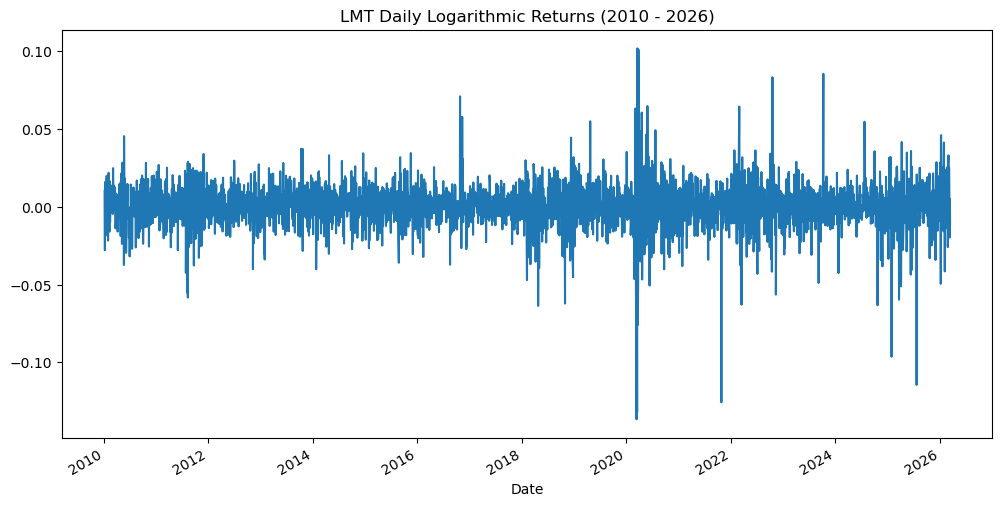

In [14]:
stock["Log Return"].plot(figsize=(12,6))
plt.title("LMT Daily Logarithmic Returns (2010 - 2026)")
plt.show()

# Conclusion & Limitations
# While the historical average annualized return provides a solid baseline, a standalone asset analysis is insufficient to formulate a definitive investment recommendation. To properly evaluate the stock's true performance, the following next steps are necessary:
# Benchmarking: Compare LMT's performance against a broader market index (e.g., S&P 500) or a sector-specific benchmark (e.g., Aerospace & Defense ETF) over the exact same time horizon.
# Risk Assessment: Incorporate risk metrics to evaluate risk-adjusted returns. Future iterations of this analysis should include calculations for volatility (annualized standard deviation), Beta, and the Sharpe ratio before advising any capital allocation.